In [10]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Dropout, Flatten, Input, MaxPooling2D, BatchNormalization
from tensorflow.keras import Model
from time import time

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set the seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

In [11]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Dataset params
num_classes = 10
size = x_train.shape[1]

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

Train set:    60000 samples
Test set:     10000 samples
Sample dims:  (60000, 28, 28)


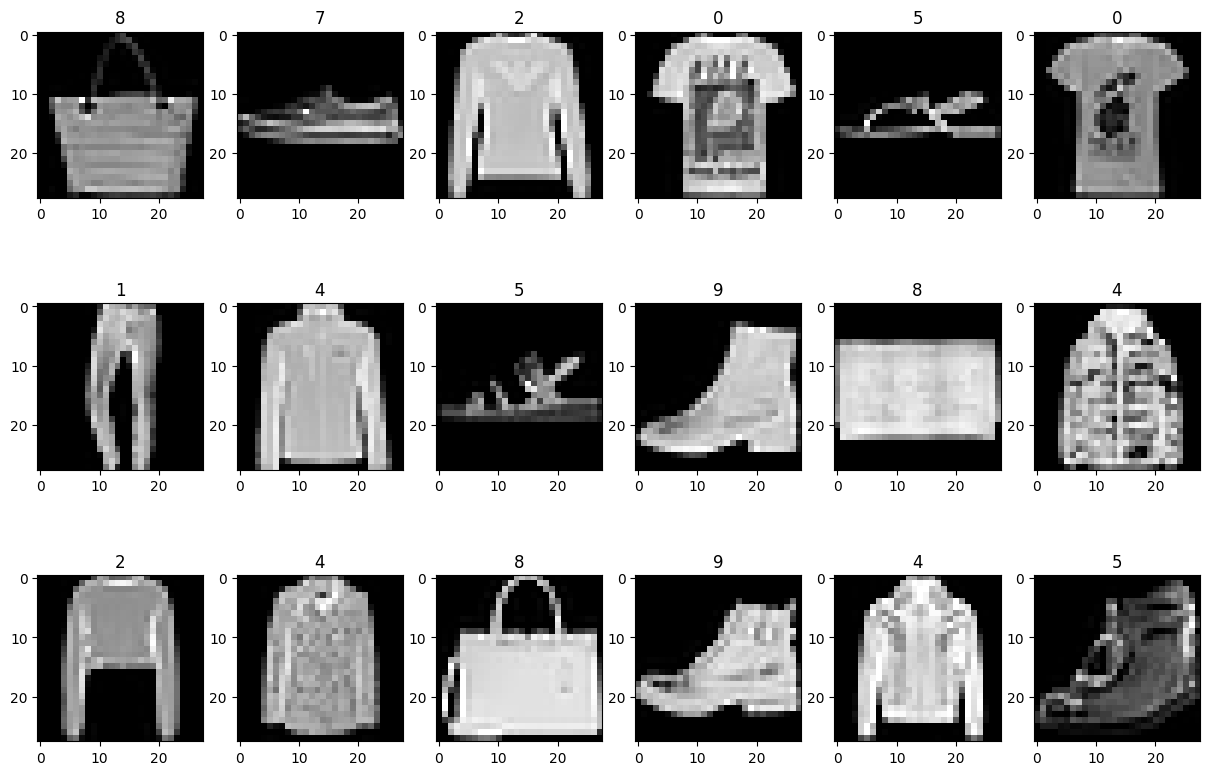

In [12]:
cnt = 1
for r in range(3):
    for c in range(6):
        idx = np.random.randint(len(x_train))
        plt.subplot(3,6,cnt)
        plt.imshow(x_train[idx, ...], cmap='gray')
        plt.title(y_train[idx])
        cnt = cnt + 1

In [13]:
# Data normalization
x_train = x_train/255
x_test = x_test/255

In [24]:
inputs = Input(shape=(28, 28, 1))
net = Conv2D(32, kernel_size=(3, 3), activation="relu", padding='same')(inputs)
net = Flatten()(net)
net = Dense(128)(net)
outputs = Dense(10, activation="softmax")(net)

model = Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,213,002 (12.26 MB)

 Trainable params: 3,213,002 (12.26 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
epochs = 50
batch_size = 64

model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_test, y_test))

Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8126 - loss: 0.6092 - val_accuracy: 0.8816 - val_loss: 0.3288
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9003 - loss: 0.2810 - val_accuracy: 0.8897 - val_loss: 0.3067
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9157 - loss: 0.2372 - val_accuracy: 0.8942 - val_loss: 0.3040
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9259 - loss: 0.2068 - val_accuracy: 0.8952 - val_loss: 0.3154
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9351 - loss: 0.1797 - val_accuracy: 0.8955 - val_loss: 0.3296
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9436 - loss: 0.1578 - val_accuracy: 0.8918 - val_loss: 0.3505
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9522 - loss: 0.1368 - val_accuracy: 0.8846 - val_loss: 0.3845
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9578 - loss: 0.1201 - v

Train Acc      0.9937999844551086
Validation Acc 0.8798999786376953


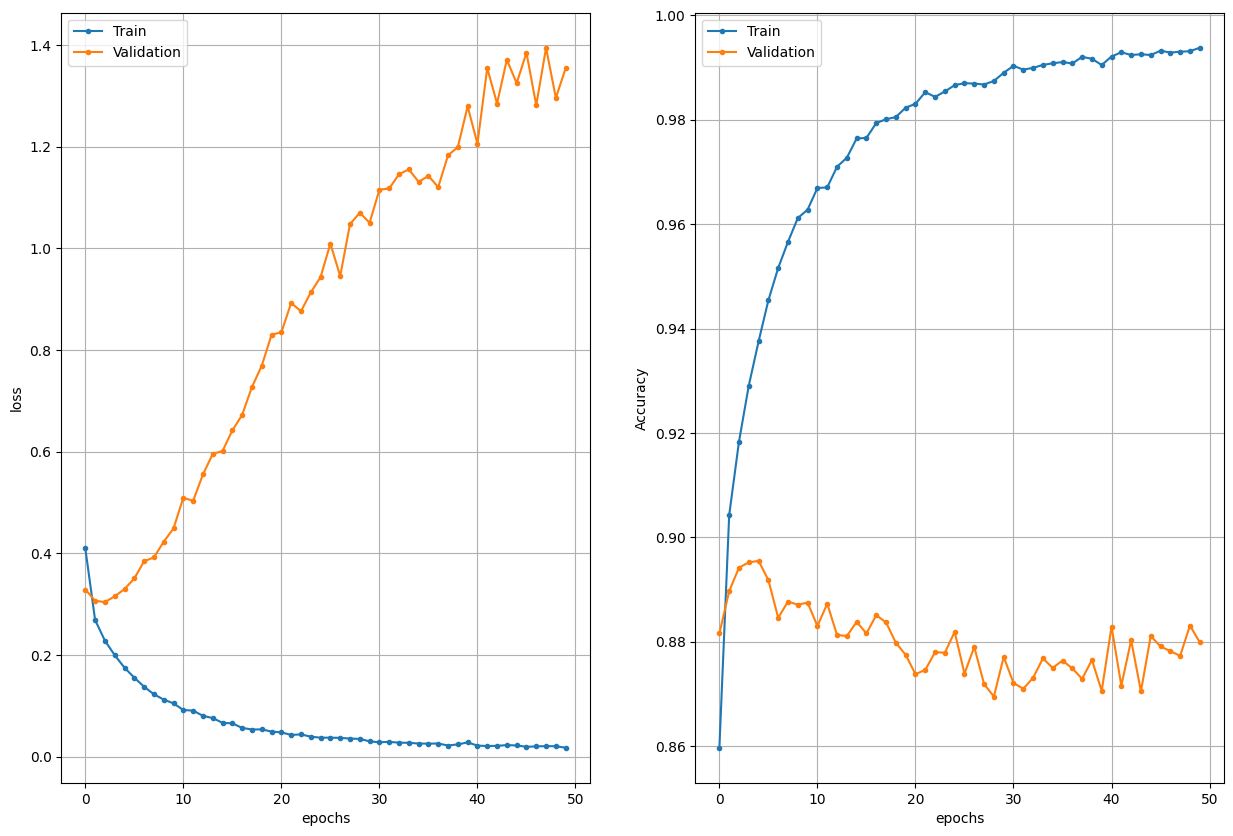

In [26]:
def plot_history(history):
    h = history.history
    epochs = range(len(h['loss']))

    plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
    plt.legend(['Train', 'Validation'])
    plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                               epochs, h['val_accuracy'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'])
        
    print('Train Acc     ', h['accuracy'][-1])
    print('Validation Acc', h['val_accuracy'][-1])
    
plot_history(history)

In [14]:
# Combat the Overfitting!
# Modify the baseline classifier in order to reduce the overfitting and make the performance more robust

# from tensorflow.keras import regularizers
from tensorflow.keras.layers import BatchNormalization


inputs = Input(shape=(28, 28, 1))
net = Conv2D(32, kernel_size=(3, 3), activation="relu", padding='same')(inputs)
net = MaxPooling2D(pool_size=(2, 2))(net)
# net = BatchNormalization()(net)
net = Dropout(0.2)(net)
net = Flatten()(net)
net = Dense(64)(net)
net = Dropout(0.5)(net)
outputs = Dense(10, activation="softmax")(net)

model = Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,442 (1.54 MB)

 Trainable params: 402,442 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Augmentation

from sklearn.utils import shuffle

def datagen(x, y, batch_size):
    num_samples = len(y)
    while True:
        for idx in range(0, num_samples, batch_size):
            x_ = x[idx:idx + batch_size, ...]
            y_ = y[idx:idx + batch_size]
            
            if len(y_) < batch_size:
                x, y = shuffle(x, y)
                break
            
            # Augmentation
            for idx_aug in range(batch_size):
                if np.random.rand() > 0.5 :
                    x_[idx_aug, ...] = np.fliplr(x_[idx_aug, ...])
                # probability = np.random.rand()
                # # (flip left <-> right with 20% probability)
                # if 0.6 < probability and probability < 0.8 :
                #     x_[idx_aug, ...] = np.fliplr(x_[idx_aug, ...])
                # # (flip up <-> down with 20% probability)
                # if probability > 0.8:
                #     x_[idx_aug, ...] = np.flipud(x_[idx_aug, ...])
                    
            yield x_, y_

batch_size = 64
generator = datagen(x_train, y_train, batch_size)

In [16]:
epochs = 50


from tensorflow.keras.callbacks import EarlyStopping
# stop callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True
)

start = time()
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model.fit(generator, steps_per_epoch=len(y_train)//batch_size, epochs=epochs, validation_data=(x_test, y_test))
print('Elapsed time', time() - start)

Epoch 1/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7518 - loss: 0.7223 - val_accuracy: 0.8604 - val_loss: 0.4008
Epoch 2/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8650 - loss: 0.3932 - val_accuracy: 0.8831 - val_loss: 0.3389
Epoch 3/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8776 - loss: 0.3512 - val_accuracy: 0.8813 - val_loss: 0.3349
Epoch 4/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8831 - loss: 0.3343 - val_accuracy: 0.8908 - val_loss: 0.3048
Epoch 5/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8919 - loss: 0.3119 - val_accuracy: 0.8891 - val_loss: 0.3078
Epoch 6/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8935 - loss: 0.3046 - val_accuracy: 0.8971 - val_loss: 0.2952
Epoch 7/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8950 - loss: 0.2949 - val_accuracy: 0.8979 - val_loss: 0.2867
Epoch 8/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8994 - loss: 0.2851 - val_

Train Acc      0.9223419427871704
Validation Acc 0.9081000089645386


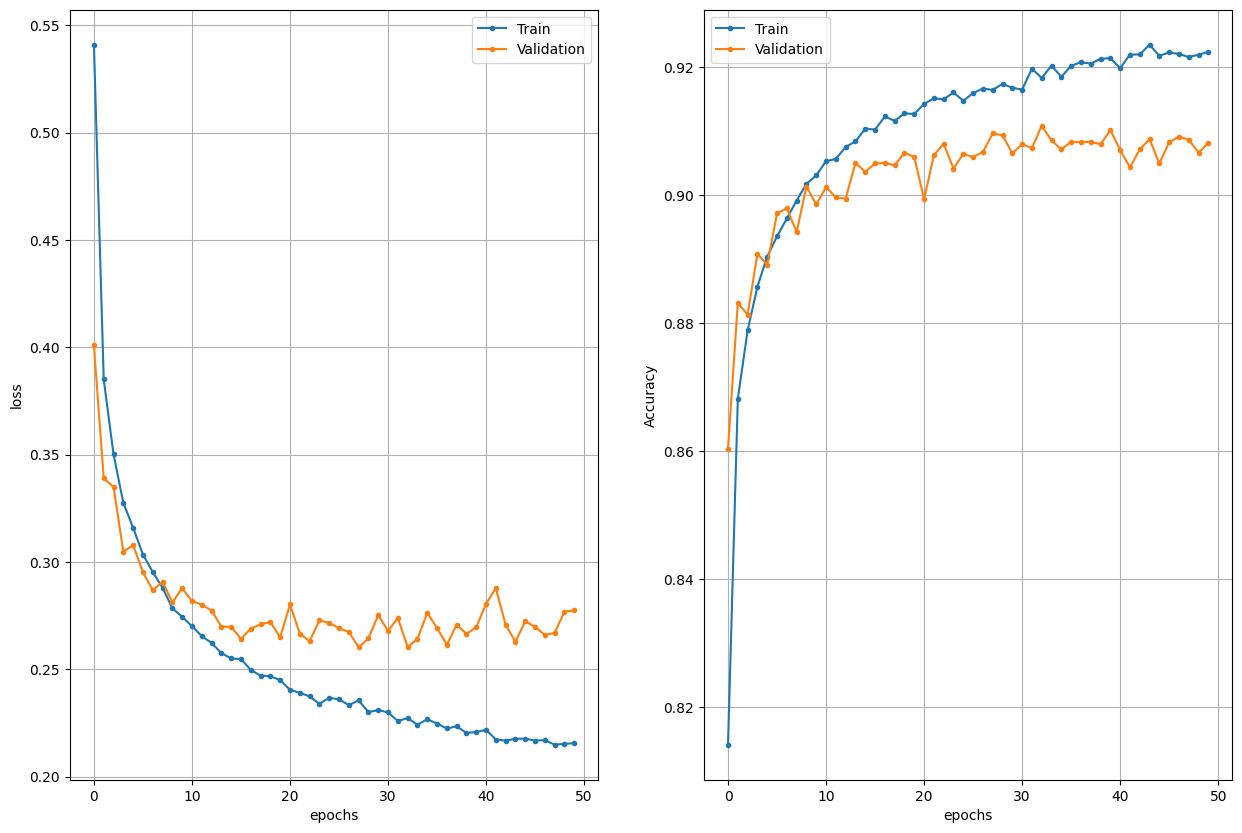

In [18]:
def plot_history(history):
    h = history.history
    epochs = range(len(h['loss']))

    plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
    plt.legend(['Train', 'Validation'])
    plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                               epochs, h['val_accuracy'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'])
        
    print('Train Acc     ', h['accuracy'][-1])
    print('Validation Acc', h['val_accuracy'][-1])
    
plot_history(history)

In [ ]:


# What have you done in order to improve the performance?
#     1) Reduced last dense layer before flatten from 128 neuron to 64
#     2) Augmentation with different image flipping
#     3) Added MaxPooling2D layer
#     4) Added dropout layer
#     5) I also tried EarlyStopping with patience=5 but it stopped training after 8-11 epochs (sometimes it finished with good accuracy, sometimes not:))
# Have you tried configurations that did not work out?
#     1) regularizers for dense layer reduce accuracy